In [1]:
import xarray as xr
import cartopy.crs as ccrs
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def define_coastal_region(sb_lat_slice,sb_lon_slice,angle_ds,lsm):
    land = xr.where(
        (angle_ds.lat<sb_lat_slice.stop) &
            (angle_ds.lat>sb_lat_slice.start) & 
            (angle_ds.lon>sb_lon_slice.start) & 
            (angle_ds.lon<sb_lon_slice.stop) & 
            (angle_ds.min_coast_dist <= 50) &
            (lsm), 1, 0 )
    land_sea = xr.where(
        (angle_ds.lat<sb_lat_slice.stop) &
            (angle_ds.lat>sb_lat_slice.start) & 
            (angle_ds.lon>sb_lon_slice.start) & 
            (angle_ds.lon<sb_lon_slice.stop) & 
            (angle_ds.min_coast_dist <= 50), 1, 0 )
    return land,land_sea

 

In [3]:
angle_ds = xr.open_dataset("/g/data/ng72/ab4502/coastline_data/barra_c.nc")
lsm = xr.open_dataset("/g/data/ob53/BARRA2/output/reanalysis/AUST-04/BOM/ERA5/historical/hres/BARRA-C2/v1/fx/sftlf/latest/sftlf_AUST-04_ERA5_historical_hres_BOM_BARRA-C2_v1.nc")

In [5]:
bris_lon_slice = slice(151,154)
bris_lat_slice = slice(-28,-27)

bris_sb_obj = xr.open_dataset("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/filters/daily_filtered_standard_F_aest_19790101_20241231.zarr/",engine="zarr",chunks={}).mask.sel(
    lat=bris_lat_slice,lon=bris_lon_slice,time=slice("1979-01-01","2024-12-31 23:59")).persist()
bris_shape = define_coastal_region(
    bris_lat_slice,
    bris_lon_slice,
    angle_ds,
    lsm.sftlf>=0.5)

bris_shape = bris_shape[0]
bris_shape_sb = xr.where(bris_shape.sel(lat=bris_lat_slice,lon=bris_lon_slice)==1,bris_sb_obj,np.nan).max(("lat","lon")).persist()
bris_shape_sb_df = bris_shape_sb.to_dataframe(name="sb")

In [6]:
perth_lon_slice = slice(115.5,116.3)
perth_lat_slice = slice(-33.3,-30.8)

perth_sb_obj = xr.open_dataset("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/filters/daily_filtered_standard_F_aest_19790101_20241231.zarr/",
                               engine="zarr",chunks={}).mask.sel(lat=perth_lat_slice,lon=perth_lon_slice,time=slice("1979-01-01","2024-12-31 23:59")).persist()
perth_shape = define_coastal_region(perth_lat_slice,perth_lon_slice,angle_ds,lsm.sftlf>=0.5)

perth_shape = perth_shape[0]
perth_shape_sb = xr.where(perth_shape.sel(lat=perth_lat_slice,lon=perth_lon_slice)==1,perth_sb_obj,np.nan).max(("lat","lon")).persist()
perth_shape_sb_df = perth_shape_sb.to_dataframe(name="sb")



# plt.figure(figsize=[12,4])
# plt.plot((shape_sb_df[shape_sb_df["sb"]==1].index.month.value_counts().sort_index() / \
#      shape_sb_df.index.month.value_counts().sort_index()).loc[[1,2,3,4,5,6,7,8,9,10,11,12]].values * 30,marker="o")
# plt.xticks(np.arange(12),np.array([1,2,3,4,5,6,7,8,9,10,11,12]).astype(str));

# masselink_data = [20,16,16.6,15,12.5,10,11,14.5,17.5,22.2,22,23]
# plt.plot(np.arange(12),masselink_data)
# plt.ylim([0,30])
# plt.gca().grid(ls=":")

In [7]:
#adelaide_lon_slice = slice(138.45,139)
adelaide_lon_slice = slice(138.45,138.75)
adelaide_lat_slice = slice(-35.3,-34.5)

adelaide_sb_obj = xr.open_dataset("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/filters/daily_filtered_standard_F_aest_19790101_20241231.zarr/",
                               engine="zarr",chunks={}).mask.sel(lat=adelaide_lat_slice,lon=adelaide_lon_slice,time=slice("1979-01-01","2024-12-31 23:59")).persist()
adelaide_shape = define_coastal_region(adelaide_lat_slice,adelaide_lon_slice,angle_ds,lsm.sftlf>=0.5)

adelaide_shape = adelaide_shape[0]
adelaide_shape_sb = xr.where(adelaide_shape.sel(lat=adelaide_lat_slice,lon=adelaide_lon_slice)==1,adelaide_sb_obj,np.nan).max(("lat","lon")).persist()
adelaide_shape_sb_df = adelaide_shape_sb.to_dataframe(name="sb")





In [8]:
#TODO: Do comparison of full boxplots?

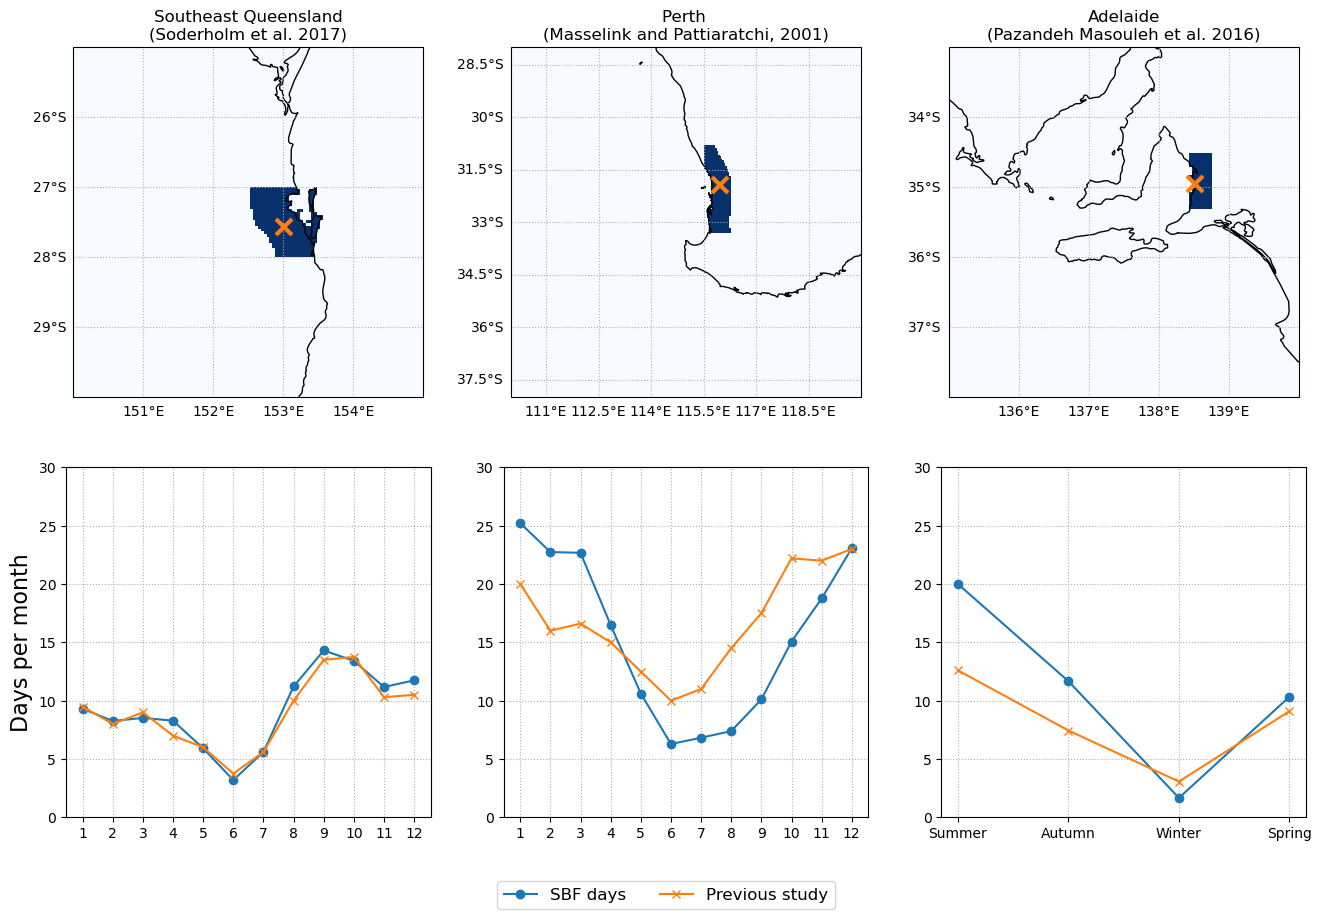

In [9]:
fig=plt.figure(figsize=[16,10])

ax=plt.subplot(2,3,1,projection=ccrs.PlateCarree())
bris_shape.plot(cmap="Blues",add_colorbar=False)
ax.plot(153.0071,-27.5716,marker="x",color="tab:orange",ms=12,mew=3)
plt.ylim([-30,-25])
plt.xlim([150,155])
ax.coastlines()
ax.gridlines(ls=":",draw_labels=["left","bottom"])
plt.title("Southeast Queensland\n(Soderholm et al. 2017)")


ax=plt.subplot(2,3,2,projection=ccrs.PlateCarree())
perth_shape.plot(cmap="Blues",add_colorbar=False)
ax.plot(115.9764,-31.9275,marker="x",color="tab:orange",ms=12,mew=3)
plt.ylim([-38,-28])
plt.xlim([110,120])
ax.coastlines()
ax.gridlines(ls=":",draw_labels=["left","bottom"])
plt.title("Perth \n(Masselink and Pattiaratchi, 2001)")


ax=plt.subplot(2,3,3,projection=ccrs.PlateCarree())
adelaide_shape.plot(cmap="Blues",add_colorbar=False)
ax.plot(138.5196,-34.9524,marker="x",color="tab:orange",ms=12,mew=3)
plt.ylim([-38,-33])
plt.xlim([135,140])
ax.coastlines()
ax.gridlines(ls=":",draw_labels=["left","bottom"])
plt.title("Adelaide\n(Pazandeh Masouleh et al. 2016)")




plt.subplot(2,3,4)
# plt.plot(
#     (bris_shape_sb_df.groupby(bris_shape_sb_df.index.month).sb.sum() / (2025-1979)).loc[[7,8,9,10,11,12,1,2,3,4,5,6]].values,
#     marker="o")
plt.plot(
    (bris_shape_sb_df.groupby(bris_shape_sb_df.index.month).sb.sum() / (2025-1979)).values,
    marker="o",color="tab:blue")

plt.xticks(np.arange(12),np.array([1,2,3,4,5,6,7,8,9,10,11,12]).astype(str));

#soderholm_data = [5.6,10,13.5,13.75,10.3,10.5,9.5,8,9,7,6,3.75]
soderholm_data = [9.5,8,9,7,6,3.75,5.6,10,13.5,13.75,10.3,10.5]
plt.plot(np.arange(12),soderholm_data,color="tab:orange",marker="x")
plt.gca().grid(ls=":")
plt.ylim([0,30])

plt.ylabel("Days per month",size=16)


plt.subplot(2,3,5)
plt.plot(
    (perth_shape_sb_df.groupby(perth_shape_sb_df.index.month).sb.sum() / (2025-1979)).values,
    marker="o",color="tab:blue")
plt.xticks(np.arange(12),np.array([1,2,3,4,5,6,7,8,9,10,11,12]).astype(str));

masselink_data = [20,16,16.6,15,12.5,10,11,14.5,17.5,22.2,22,23]
plt.plot(np.arange(12),masselink_data,color="tab:orange",marker="x")

plt.ylim([0,30])
plt.gca().grid(ls=":")



plt.subplot(2,3,6)
#monthly_percent = (adelaide_shape_sb_df[adelaide_shape_sb_df["sb"]==1].index.month.value_counts().sort_index() / \
#     adelaide_shape_sb_df.index.month.value_counts().sort_index()).loc[[1,2,3,4,5,6,7,8,9,10,11,12]].values

# seasonal_percent = [
#     ((monthly_percent[0] + monthly_percent[1] + monthly_percent[11])/3 * 90 / 3),
#     ((monthly_percent[2] + monthly_percent[3] + monthly_percent[4])/3 * 93 / 3),
#     ((monthly_percent[5] + monthly_percent[6] + monthly_percent[7])/3 * 92 / 3),
#     ((monthly_percent[8] + monthly_percent[9] + monthly_percent[10])/3 * 91 / 3)
#     ]

adelaide_shape_sb_df["season"] = adelaide_shape_sb_df.index.month.map({
            1:"DJF",2:"DJF",12:"DJF",
            3:"MAM",4:"MAM",5:"MAM",
            6:"JJA",7:"JJA",8:"JJA",
            9:"SON",10:"SON",11:"SON",
        })

adelaide_shape_sb_df["year"] = adelaide_shape_sb_df.index.year.astype(str)

seasonal_percent = [adelaide_shape_sb_df[adelaide_shape_sb_df["season"]==s].groupby("year").sb.sum().median()/3 for s in ["DJF","MAM","JJA","SON"]]

l1=plt.plot([0,1,2,3],seasonal_percent,marker="o",color="tab:blue")
l2=plt.plot([.42*90/3,.24*93/3,.10*92/3,.30*91/3],color="tab:orange",marker="x")
plt.xticks(np.arange(4),np.array(["Summer","Autumn","Winter","Spring"]).astype(str));

plt.ylim([0,30])
plt.gca().grid(ls=":")


fig.legend([l1[0],l2[0]],["SBF days","Previous study"],bbox_to_anchor=(0.5,0.01),ncols=2,loc="lower center",fontsize="large")


plt.savefig("/g/data/ng72/ab4502/figs/wind_energy_paper/previous_study_compare.jpeg",bbox_inches="tight",dpi=300)

In [10]:
years = np.arange(1997,2015)
sb_days_per_year = []
for y in years:
    sb_days_per_year.append(bris_shape_sb_df.loc[slice(str(y)+"-07-01",str(y+1)+"-06-30 23:00")].sb.sum())

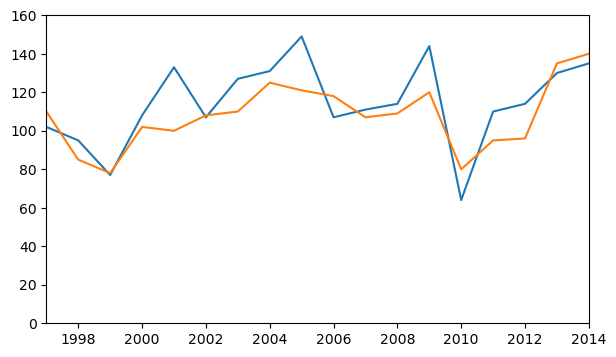

In [12]:
plt.figure(figsize=[7,4])
plt.plot(years,np.array(sb_days_per_year))
plt.ylim([0,160])
plt.xlim([1997,2014])

soderholm = [110,85,78,102,100,108,110,125,121,118,107,109,120,80,95,96,135,140]
plt.plot(years,soderholm)

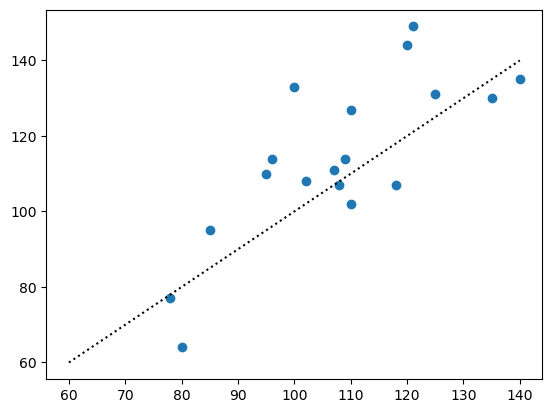

In [16]:
plt.scatter(soderholm,np.array(sb_days_per_year))
plt.plot([60,140],[60,140],ls=":",color="k")